In [35]:
# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [36]:
# Path

skyline_path = 'data/MARTHA/DE17501_Martha_results_dotp.csv'
## Read data
skyline_data = pd.read_csv(skyline_path)
# ## For skyline data, remove column Precursor and drop duplicates
# skyline_data = skyline_data.drop(columns=['Precursor'])



# SDRF 
sdrf_data = pd.read_csv('sdrf/sdrf_MARTHA_combined.sdrf.tsv', sep='\t')
# Save the combined sdrf data to a file
# sdrf_data.to_csv('export/sdrf_MARTHA_combined.tsv', sep='\t', index=False)




In [37]:
skyline_data[['Protein Name']].to_csv('export/protein_names.csv', index=False)
irt_tag_protein = skyline_data[skyline_data['Protein Name'].str.contains('iRT_Tag')] 
iRT_peptides = skyline_data['Peptide Sequence'][skyline_data['Protein Name'].str.contains('iRT_Tag')]
iRT_peptides = iRT_peptides.drop_duplicates().tolist()

print(iRT_peptides)

['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']


In [ ]:
# (Optional) Save the table to a CSV file in the current folder
output_path = f"qreps_{lot_or_lot.strip().strip('/')}.csv"
qreps_df.to_csv(output_path, index=False)
print(f"Saved qRePS table to: {output_path}")

Text(0.5, 0, 'Library Dot Product')

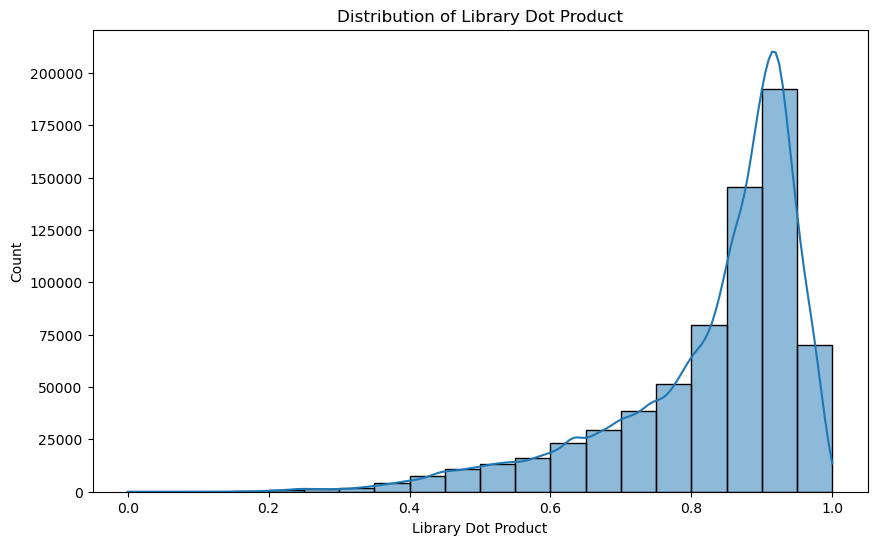

In [38]:
# Plot distrion of Library Dot Product

# Plot distribution of Library Dot Product
plt.figure(figsize=(10, 6))
sns.histplot(skyline_data['Library Dot Product'], bins=20, kde=True)
plt.title('Distribution of Library Dot Product')
plt.xlabel('Library Dot Product')

In [39]:
skyline_data

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name
0,490.5796+++ (heavy),PRM_20251128_MarthaReselection_QC,PRM_20251128_MarthaReselection_QC.raw,13.28,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9169,iRT_Tag
1,490.5796+++ (heavy),PRM_20251128_MarthaReselection_QC_20251128151944,PRM_20251128_MarthaReselection_QC_202511281519...,13.37,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9176,iRT_Tag
2,490.5796+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_F4,PRM_20251128_MarthaReselection_Plate_1_F4.raw,13.31,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9000,iRT_Tag
3,490.5796+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B6,PRM_20251128_MarthaReselection_Plate_1_B6.raw,13.43,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9205,iRT_Tag
4,490.5796+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_A3,PRM_20251128_MarthaReselection_Plate_1_A3.raw,13.35,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9445,iRT_Tag
...,...,...,...,...,...,...,...,...,...,...,...,...,...
685979,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_A3,PRM_20251218_MarthaReselection_Plate_9_A3.raw,25.53,111.28,24.83,TLAFPLTIR,TLAFPLTIR,6.1168E+4,0.3779,NaN,0.9056,QR7000010_PROCR|Q9UNN8
685980,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_G6,PRM_20251218_MarthaReselection_Plate_9_G6.raw,25.54,111.28,24.83,TLAFPLTIR,TLAFPLTIR,1.1438E+5,0.7279,NaN,0.9041,QR7000010_PROCR|Q9UNN8
685981,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_C8,PRM_20251218_MarthaReselection_Plate_9_C8.raw,25.45,111.28,24.83,TLAFPLTIR,TLAFPLTIR,1.4815E+5,0.9598,NaN,0.8651,QR7000010_PROCR|Q9UNN8
685982,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_B7,PRM_20251218_MarthaReselection_Plate_9_B7.raw,25.54,111.28,24.83,TLAFPLTIR,TLAFPLTIR,7.2499E+4,0.5697,NaN,0.9182,QR7000010_PROCR|Q9UNN8


In [40]:
import re

# Add column Isotope Label Type
skyline_data['Isotope Label Type'] = skyline_data['Precursor'].apply(lambda x: 'heavy' if re.search(r'heavy', str(x), re.IGNORECASE) else 'light')

# Filter out library dot product that is less than 0.6
skyline_data = skyline_data[skyline_data['Library Dot Product'] > 0.6]

# # Remove Normalied Area that is Nan
skyline_data = skyline_data[skyline_data['Normalized Area'].notna()]
# # Prepare pivot table, keeping all other column names as index except 'Isotope Label Type' and 'Intensity'
index_cols = [col for col in skyline_data.columns if col not in ['Isotope Label Type', 'Intensity']]
skyline_pivot = skyline_data.pivot_table(
    index=['Replicate', 'Peptide'],
    columns='Isotope Label Type',
    values='Normalized Area',
    aggfunc='first'
).reset_index()

# # Calculate lh_ratio
# skyline_pivot['lh_ratio'] = skyline_pivot['heavy'] / skyline_pivot['light']


skyline_pivot.head(20)


Isotope Label Type,Replicate,Peptide,heavy,light
0,PRM_20251128_MarthaReselection_Plate_1_A1,AAPAPQEATATFNSTADREDGHR,1.3533E+4,1.3533E+4
1,PRM_20251128_MarthaReselection_Plate_1_A1,AAVYHHFISDGVR,1.4852E+6,1.4852E+6
2,PRM_20251128_MarthaReselection_Plate_1_A1,AAVYHHFISDGVRK,3.3933E+6,3.3933E+6
3,PRM_20251128_MarthaReselection_Plate_1_A1,ACIPTGPYPCGK,8.8676E+5,8.8676E+5
4,PRM_20251128_MarthaReselection_Plate_1_A1,ADQVCINLR,6.1058E+5,6.1058E+5
5,PRM_20251128_MarthaReselection_Plate_1_A1,AEATTLHVAPQGTAMAVSTFR,3.9976E+5,3.9976E+5
6,PRM_20251128_MarthaReselection_Plate_1_A1,AFLLTPR,8.0163E+6,8.0163E+6
7,PRM_20251128_MarthaReselection_Plate_1_A1,AFVNCDENSR,*1.5065E+5,*1.5065E+5
8,PRM_20251128_MarthaReselection_Plate_1_A1,AGGQCPACGGPTLELESQR,1.9611E+6,1.9611E+6
9,PRM_20251128_MarthaReselection_Plate_1_A1,AGGSWDLAVQER,1.0415E+6,1.0415E+6


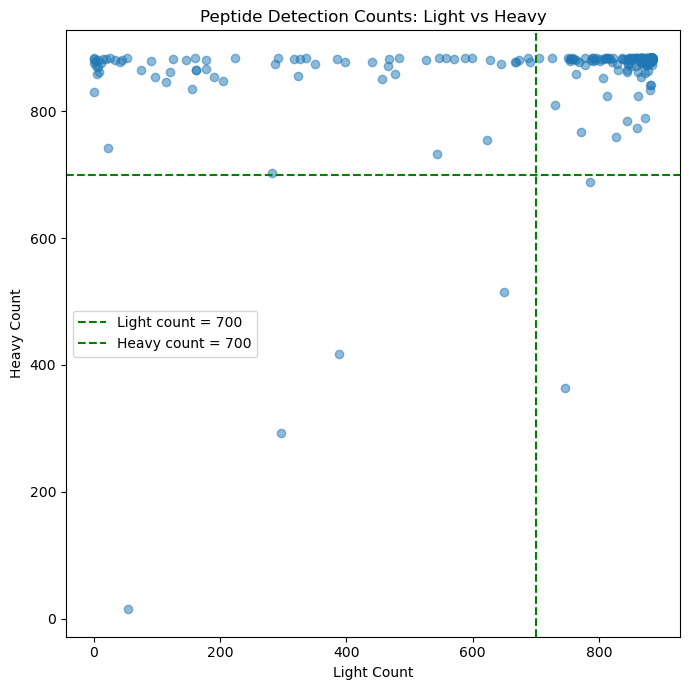

In [41]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = skyline_pivot.groupby('Peptide').agg(
    heavy_count=pd.NamedAgg(column='heavy', aggfunc=lambda x: x.notna().sum()),
    light_count=pd.NamedAgg(column='light', aggfunc=lambda x: x.notna().sum())
).reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(peptide_counts['light_count'], peptide_counts['heavy_count'], alpha=0.5)
plt.axvline(700, color='g', linestyle='--', label='Light count = 700')
plt.axhline(700, color='g', linestyle='--', label='Heavy count = 700')
plt.xlabel('Light Count')
plt.ylabel('Heavy Count')
plt.title('Peptide Detection Counts: Light vs Heavy')
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# Sumamrise Protein and Peptide that has been detected the least
# Count the number of unique peptides and proteins in the data
num_unique_peptides = skyline_data['Peptide'].nunique()

# If Protein Name is not present in peptide_counts (from pivot), map it from skyline_data
if 'Protein Name' in skyline_data.columns:
    num_unique_proteins = skyline_data['Protein Name'].nunique()
else:
    num_unique_proteins = 0

print(f"Number of unique peptides: {num_unique_peptides}")
print(f"Number of unique proteins: {num_unique_proteins}")

# For peptide_counts, Protein Name is missing, so we need to map peptide->protein using skyline_data
peptide_to_protein = skyline_data[['Peptide', 'Protein Name']].drop_duplicates().set_index('Peptide')['Protein Name']

# Add Protein Name to peptide_counts for peptide-based summaries
peptide_counts = peptide_counts.merge(peptide_to_protein, left_on='Peptide', right_index=True, how='left')

# Peptides detected only once in heavy (rare peptides)
least_detected_peptides = peptide_counts[peptide_counts['heavy_count'] == 1]['Peptide'].nunique()
least_detected_proteins = peptide_counts[peptide_counts['heavy_count'] == 1]['Protein Name'].nunique()

# Counting unique peptides with only 1 detection in light/heavy signal
least_detected_light = peptide_counts[peptide_counts['light_count'] == 1].shape[0]
least_detected_heavy = peptide_counts[peptide_counts['heavy_count'] == 1].shape[0]

print(f"Number of peptides detected only once in heavy: {least_detected_peptides}")
print(f"Number of proteins (containing such peptides) detected only once in heavy: {least_detected_proteins}")

print(f"Number of peptides detected only once in light: {least_detected_light}")
print(f"Number of peptides detected only once in heavy: {least_detected_heavy}")




Number of unique peptides: 382
Number of unique proteins: 176
Number of peptides detected only once in heavy: 0
Number of proteins (containing such peptides) detected only once in heavy: 0
Number of peptides detected only once in light: 1
Number of peptides detected only once in heavy: 0


Number of peptides detected in the cutoff: 310
Number of proteins detected in the cutoff: 149


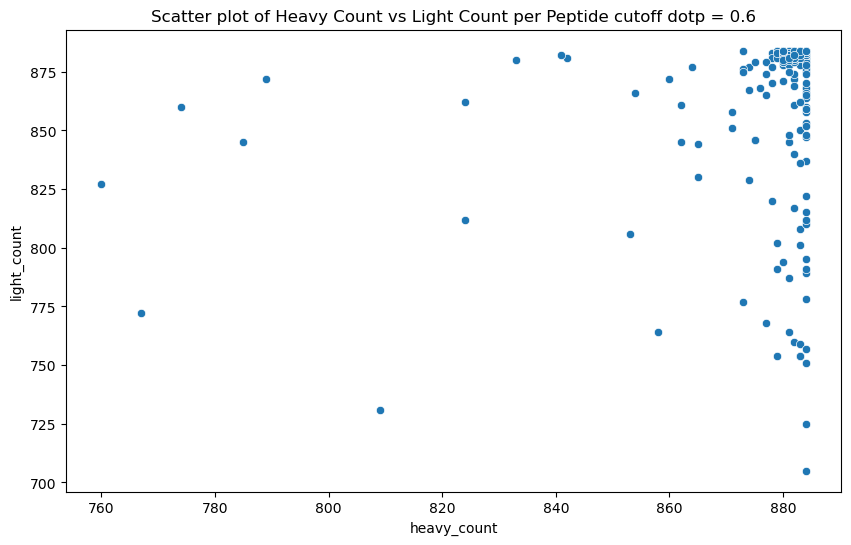

In [43]:
# Set the cut off at 700 on both light and heavy count and then summarise the peptide list and plot the scatter again
peptide_counts_cutoff = peptide_counts[(peptide_counts['heavy_count'] > 700) & (peptide_counts['light_count'] > 700)]



# Summarise how many peptide and protein are detected in the cutoff
peptide_counts_cutoff['Peptide'].nunique()
print(f"Number of peptides detected in the cutoff: {peptide_counts_cutoff['Peptide'].nunique()}")

# Fitlered peptides list 
selected_peptides = peptide_counts_cutoff['Peptide'].drop_duplicates().tolist()
peptide_counts_cutoff['Protein Name'].nunique()
print(f"Number of proteins detected in the cutoff: {peptide_counts_cutoff['Protein Name'].nunique()}")

# Plot the scatter again
plt.figure(figsize=(10, 6))
sns.scatterplot(x='heavy_count', y='light_count', data=peptide_counts_cutoff)
plt.title('Scatter plot of Heavy Count vs Light Count per Peptide cutoff dotp = 0.6')
plt.xlabel('heavy_count')
plt.ylabel('light_count')
plt.show()

In [44]:
# Pick theese columns from skyline_data
select_col = ['Replicate', 'Peptide Sequence', 'Protein Name', 'RatioLightToHeavy']

# Filtered skyline_data with selected_peptides
skyline_data_filtered = skyline_data[skyline_data['Peptide'].isin(selected_peptides)]

# Se;ect Replciate, Peptide Sequence, Protein Name and RatioLighToHeavy from skyline_data_filtered
skyline_data_filtered = skyline_data_filtered[select_col].drop_duplicates()


# Merge skyline_data_filtered with sdrf_data using 'Replicate' from skyline and 'comment[data file]' from sdrf_data
skyline_merge = pd.merge(skyline_data_filtered, sdrf_data[['source name', 'characteristics[Sample]']], left_on='Replicate', right_on='source name', how='left')

# Create column characteristics[Plate] from characteristics[Sample] (should be whatever comes after 'Plate_' in Replicate)
skyline_merge['characteristics[Plate]'] = skyline_merge['Replicate'].str.extract(r'Plate_(\d+)')




In [45]:
pool_data = skyline_merge[skyline_merge['characteristics[Sample]'] == 'Pool']
pool_data.head()

,Replicate,Peptide Sequence,Protein Name,RatioLightToHeavy,source name,characteristics[Sample],characteristics[Plate]
8,PRM_20251128_MarthaReselection_Plate_1_F12,ISASAEELR,QR0260124_APOA4|P06727,2.0947,PRM_20251128_MarthaReselection_Plate_1_F12,Pool,1
26,PRM_20251128_MarthaReselection_Plate_1_D10,ISASAEELR,QR0260124_APOA4|P06727,2.0788,PRM_20251128_MarthaReselection_Plate_1_D10,Pool,1
36,PRM_20251128_MarthaReselection_Plate_1_G12,ISASAEELR,QR0260124_APOA4|P06727,2.0307,PRM_20251128_MarthaReselection_Plate_1_G12,Pool,1
50,PRM_20251128_MarthaReselection_Plate_1_H12,ISASAEELR,QR0260124_APOA4|P06727,2.0660,PRM_20251128_MarthaReselection_Plate_1_H12,Pool,1
51,PRM_20251128_MarthaReselection_Plate_1_B2,ISASAEELR,QR0260124_APOA4|P06727,2.2609,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1


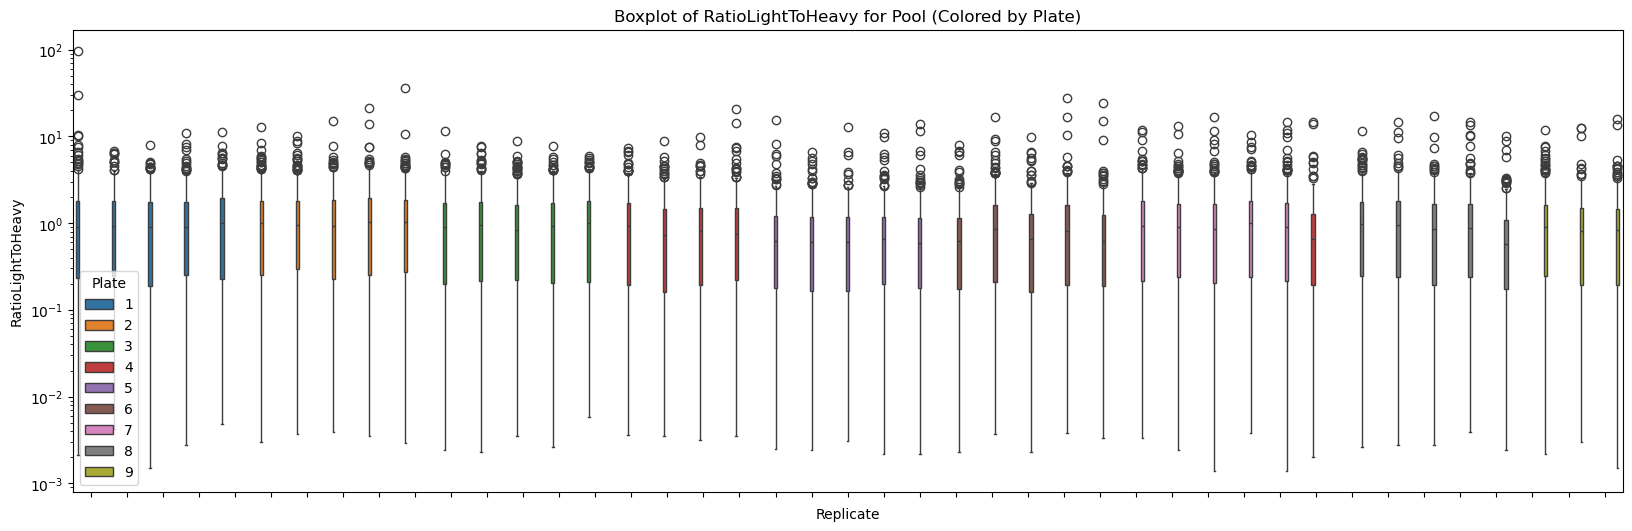

In [46]:

# Plot boxplot of RatioLightToHeavy for pool_data by Replicate, colored by Plate
plt.figure(figsize=(20, 6))
sns.boxplot(
    x='Replicate',
    y='RatioLightToHeavy',
    data=pool_data,
    hue='characteristics[Plate]',
    dodge=True
)
plt.title('Boxplot of RatioLightToHeavy for Pool (Colored by Plate)')
plt.xlabel('Replicate')
plt.ylabel('RatioLightToHeavy')
plt.yscale('log')
plt.gca().set_xticklabels([])
plt.legend(title='Plate')
plt.show()


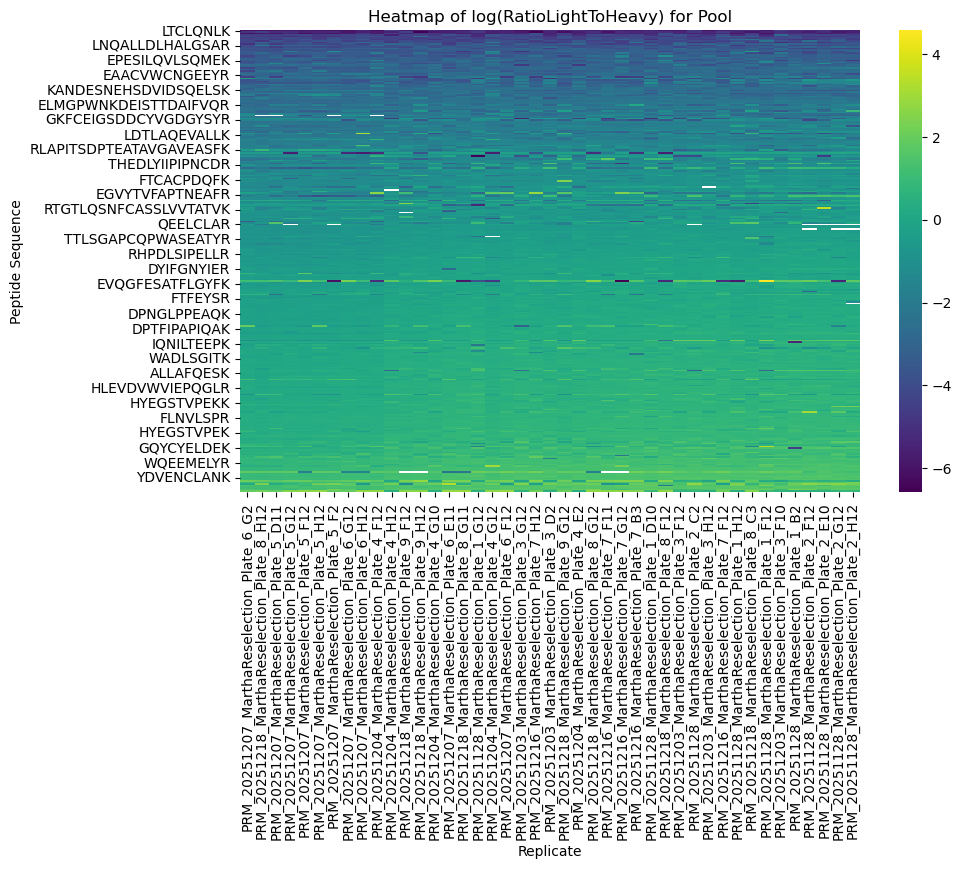

In [47]:
pivot = pool_data.pivot(
    index='Peptide Sequence',
    columns='Replicate',
    values='RatioLightToHeavy'
)

# log-transform (assumes RatioLightToHeavy > 0)
heatmap_data = np.log(pivot)

# sort replicates (columns, x-axis) by their mean log-ratio
col_order = heatmap_data.mean(axis=0).sort_values().index

# sort peptides (rows, y-axis) by their mean log-ratio
row_order = heatmap_data.mean(axis=1).sort_values().index

# apply both orders
heatmap_data = heatmap_data.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Heatmap of log(RatioLightToHeavy) for Pool')
plt.xlabel('Replicate')
plt.ylabel('Peptide Sequence')
plt.show()

,characteristics[Plate],Peptide Sequence,mean,std,intra_plate_cv
0,1,AAVYHHFISDGVR,0.88408,0.492877,0.557502
1,1,AAVYHHFISDGVRK,1.09988,0.146371,0.133079
2,1,ACIPTGPYPCGK,0.96442,0.057612,0.059738
3,1,ADQVCINLR,0.63904,0.033475,0.052382
4,1,AEATTLHVAPQGTAMAVSTFR,1.90414,0.255476,0.134169


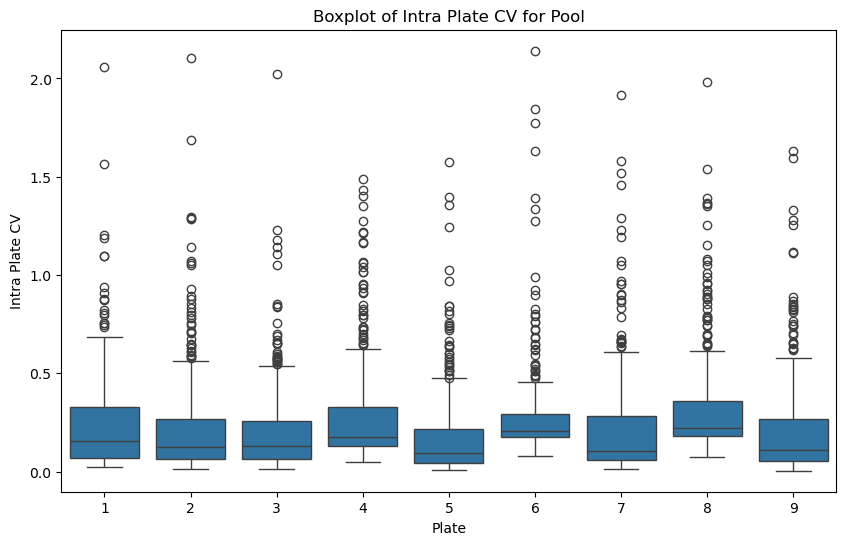

In [48]:
# Calculate inter-plate CV per peptide and summarise in a dataframe

# Group by Plate and Peptide Sequence, calculate mean and std for each, then compute intra-plate CV
peptide_plate_stats = (
    pool_data.groupby(['characteristics[Plate]', 'Peptide Sequence'])['RatioLightToHeavy']
    .agg(['mean', 'std'])
    .reset_index()
)
peptide_plate_stats['intra_plate_cv'] = peptide_plate_stats['std'] / peptide_plate_stats['mean']

# Show summary dataframe
display(peptide_plate_stats.head())


plt.figure(figsize=(10, 6))
sns.boxplot(x='characteristics[Plate]', y='intra_plate_cv', data=peptide_plate_stats)
plt.title('Boxplot of Intra Plate CV for Pool')
plt.xlabel('Plate')
plt.ylabel('Intra Plate CV')
plt.show()


In [63]:
peptide_plate_stats.head()

,characteristics[Plate],Peptide Sequence,mean,std,intra_plate_cv
0,1,AAVYHHFISDGVR,0.88408,0.492877,0.557502
1,1,AAVYHHFISDGVRK,1.09988,0.146371,0.133079
2,1,ACIPTGPYPCGK,0.96442,0.057612,0.059738
3,1,ADQVCINLR,0.63904,0.033475,0.052382
4,1,AEATTLHVAPQGTAMAVSTFR,1.90414,0.255476,0.134169


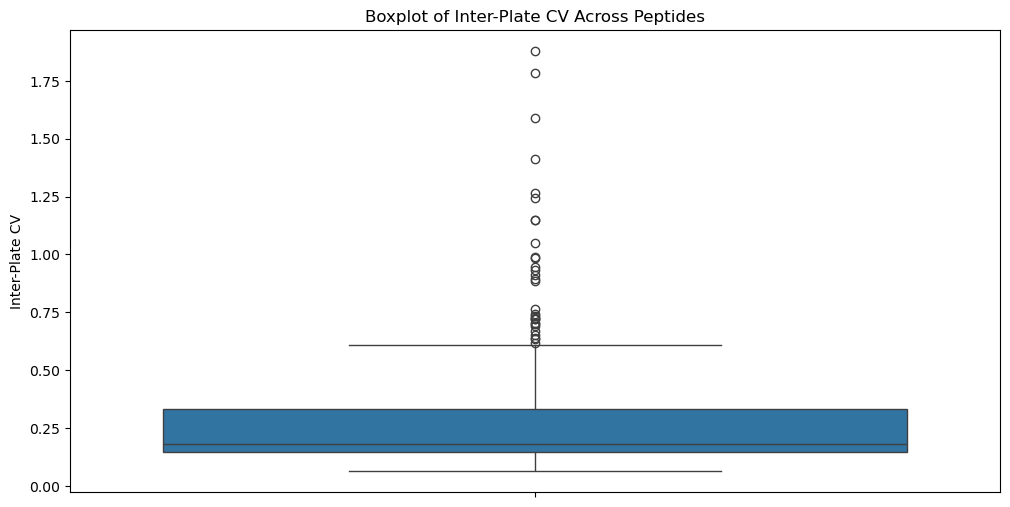

In [ ]:
# From pool data, plot box plot of ratio 
# Now, summarise inter-plate CV for each peptide (i.e., how the mean RatioLightToHeavy varies across plates)


# Group by Peptide Sequence and calculate the mean and sd of RatioLightToHeavy, summarise in df
peptide_means = (
    peptide_plate_stats.groupby('Peptide Sequence')['mean']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'grand_mean', 'std': 'between_plate_sd'})
    .reset_index()
)

# Calculate inter-plate CV per peptide
peptide_means['inter_plate_cv'] = peptide_means['between_plate_sd'] / peptide_means['grand_mean']

# Display summarised dataframe of inter-plate CV per peptide
peptide_means[['Peptide Sequence', 'inter_plate_cv']].head()

# Plot boxplot of inter-plate CV by peptide
plt.figure(figsize=(12, 6))
sns.boxplot(y='inter_plate_cv', data=peptide_means)
plt.title('Boxplot of Inter-Plate CV Across Peptides')
plt.ylabel('Inter-Plate CV')
plt.xlabel('')
plt.show()



In [50]:
# How many peptide below 20% CV
peptide_means[peptide_means['inter_plate_cv'] < 0.2]['Peptide Sequence'].nunique()
print(f"Number of peptides below 20% CV: {peptide_means[peptide_means['inter_plate_cv'] < 0.2]['Peptide Sequence'].nunique()}")

# How many peptide below 10% CV
peptide_means[peptide_means['inter_plate_cv'] < 0.1]['Peptide Sequence'].nunique()
print(f"Number of peptides below 10% CV: {peptide_means[peptide_means['inter_plate_cv'] < 0.1]['Peptide Sequence'].nunique()}")

Number of peptides below 20% CV: 175
Number of peptides below 10% CV: 6


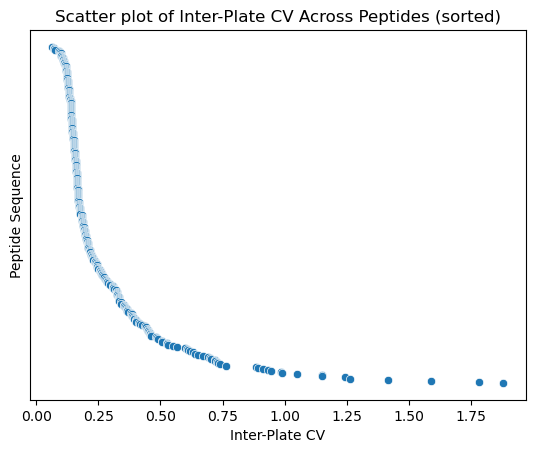

In [51]:
# Plot CV of each peptide in scatter plot, sorted by CV, and hide y labels entirely
peptide_means_sorted = peptide_means.sort_values('inter_plate_cv', ascending=True)
ax = sns.scatterplot(
    x='inter_plate_cv',
    y='Peptide Sequence',
    data=peptide_means_sorted
)
plt.title('Scatter plot of Inter-Plate CV Across Peptides (sorted)')
plt.xlabel('Inter-Plate CV')
ax.set_ylabel('Peptide Sequence')
ax.set_yticklabels([])
ax.set_yticks([])
plt.show()

In [60]:
plate_norm_median.head()

characteristics[Plate]
1    0.6783
2    0.6718
3    0.6894
4    0.6380
5    0.5057
Name: RatioLightToHeavy, dtype: float64

In [62]:
plate_norm_median.head()

characteristics[Plate]
1    0.6783
2    0.6718
3    0.6894
4    0.6380
5    0.5057
Name: RatioLightToHeavy, dtype: float64

In [ ]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

# Find the threshold for the top 10% lowest inter-plate CV peptides
cv_threshold = peptide_means['inter_plate_cv'].quantile(0.1)
# Get list of peptides in the top 10% lowest inter-plate CV
top10cv_peptides = peptide_means[peptide_means['inter_plate_cv'] <= cv_threshold]['Peptide Sequence'].unique()

# Filter pool_data to include only those peptides for normalization calculation
norm_data = pool_data[pool_data['Peptide Sequence'].isin(top10cv_peptides)]


# Global median RatioLightToHeavy for normalization peptides - do it per peptide:
global_norm_median_per_peptide = (
    norm_data.groupby('Peptide Sequence')['RatioLightToHeavy'].median()
)

# Calculate global conversion factor for each plate by dividing global_norm_median_per_peptide by plate_norm_median
global_conversion_factor = global_norm_median_per_peptide / plate_norm_median


# Map normalization medians to the full dataset for batch correction
pool_data['batch_plate_norm_median'] = pool_data['characteristics[Plate]'].map(plate_norm_median)

/tmp/ipykernel_849964/721334781.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pool_data['batch_plate_norm_median'] = pool_data['characteristics[Plate]'].map(plate_norm_median)


In [57]:
global_norm_median

np.float64(0.6689)

In [ ]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) from top 10% lowest CV peptides


# Calculate median RatioLightToHeavy for each peptide within each plate
peptide_plate_median = (
    pool_data.groupby(['Peptide Sequence', 'characteristics[Plate]'])['RatioLightToHeavy']
    .median()
)

# Calculate global median RatioLightToHeavy for each peptide across all plates
peptide_global_median = (
    pool_data.groupby('Peptide Sequence')['RatioLightToHeavy']
    .median()
)

# Generate mapping for quick access
pool_data['peptide_plate_median'] = pool_data.set_index(['Peptide Sequence', 'characteristics[Plate]']).index.map(peptide_plate_median)
pool_data['peptide_plate_median'] = [
    peptide_plate_median.loc[(row['Peptide Sequence'], row['characteristics[Plate]'])]
    for _, row in pool_data.iterrows()
]

pool_data['peptide_global_median'] = pool_data['Peptide Sequence'].map(peptide_global_median)

# Calculate batch-normalized ratio for each peptide within each plate
pool_data['batch_normalized'] = pool_data['RatioLightToHeavy'] / pool_data['peptide_plate_median']

# # Calculate correction factor for each peptide on each plate
correction_factor = pool_data['peptide_global_median'] / pool_data['peptide_plate_median']

pool_data['batch_corrected'] = pool_data['batch_normalized'] * correction_factor

/tmp/ipykernel_849964/45335031.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pool_data['peptide_plate_median'] = pool_data.set_index(['Peptide Sequence', 'characteristics[Plate]']).index.map(peptide_plate_median)
/tmp/ipykernel_849964/45335031.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pool_data['peptide_plate_median'] = [
/tmp/ipykernel_849964/45335031.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [25]:
peptide_global_median

Peptide Sequence
AAVYHHFISDGVR            0.8456
AAVYHHFISDGVRK           1.0339
ACIPTGPYPCGK             0.9221
ADQVCINLR                0.5929
AEATTLHVAPQGTAMAVSTFR    1.3938
                          ...  
YLQGSSVQLR               0.6324
YRITENDIQIALDDAK         1.1042
YSFLAR                   1.2441
YVMLPVADQDQCIR           1.6178
YYCFQGNQFLR              4.6644
Name: RatioLightToHeavy, Length: 310, dtype: float64